In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression as LR
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
from scipy import stats
from scipy.special import binom
import matplotlib.pyplot as plt
import time 
import abess
from abess.linear import LinearRegression
from scipy.linalg import toeplitz

# ignore DataConversionWanning
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

In [2]:
def get_data(eps, iter, signal, num_chains, data_type) :
    dir_name = data_type + "/eps_" + str(eps) + "_iter_" + str(iter) + "_" + signal
    X = pd.read_csv(dir_name + "/data_X.csv", header=None)
    y = pd.read_csv(dir_name + "/data_y.csv", header=None)
    beta = pd.read_csv(dir_name + "/data_beta.csv", header=None)

    temp = list() # initalize empty dataframe
    f1_temp = list()

    for i in range(num_chains) :
        file_name = "/chain_" + str(i+1) + "_eps_" + str(eps) + "_iter_" + str(iter) + ".csv"
        result = pd.read_csv(dir_name + file_name, header=None, index_col=None)
        temp.append(result)

        f1_file_name = "/F1_chain_" + str(i+1) + "_eps_" + str(eps) + "_iter_" + str(iter) + ".csv"
        f1 = pd.read_csv(dir_name + f1_file_name, header=None, index_col=None)
        f1_temp.append(f1)

    RSS = pd.concat(temp, axis=1, ignore_index=True)
    F1_scores = pd.concat(f1_temp, axis=1, ignore_index=True)
    F1 = F1_scores.iloc[:-1]
    sens_scale = F1_scores.iloc[-1][0]

    return {'RSS': RSS, 'F1': F1, 'Sensitivity_scale': sens_scale, 'X': X, 'y': y, 'beta': beta}

def get_graph(eps, iter, signal, num_chains, data_type) :
    data = get_data(eps, iter, signal, num_chains, data_type)
    RSS_all = data['RSS']
    F1 = data['F1']
    Sens_scale = data['Sensitivity_scale']
    X = data['X']
    y = data['y']
    beta = data['beta']

    # parameter of data
    n, p = X.shape
    s = 10

    # ABESS
    model_abess = LinearRegression(support_size = s)
    model_abess.fit(X, y)
    S_abess = np.where(model_abess.coef_!=0)[0]
    S = np.where(beta!=0)[0]
    prec = len(np.intersect1d(S_abess, S))/max(1,len(S_abess))
    recall = len(np.intersect1d(S_abess, S))/len(S)
    F1_abess = 2/(1/prec + 1/recall)

    RSS_abess = np.linalg.norm(y - X@model_abess.coef_.reshape((-1, 1)))**2/np.linalg.norm(y)**2
    RSS_true = np.linalg.norm(y - X@beta)**2/np.linalg.norm(y)**2

    print('F_gamma^* :', 1-RSS_true)
    print('F_gamma_BSS :', 1-RSS_abess)

    plt.axhline(y = 1- RSS_true, color = 'b', linestyle = '--', label = '$F_{\gamma^*}$')
    plt.axhline(y = 1- RSS_abess, color = 'r', linestyle = '--', label = '$F_{\gamma_{BSS}}(non-private)$')

    for i in range(num_chains):
        RSS = RSS_all.loc[:,i]
        if i==0: plt.plot(range(len(RSS)), (1-RSS), color = 'grey', alpha = 0.3, label = '$F_{\gamma_{BSS}}(\epsilon = $' + 
                        str(eps) + ')')
        else: plt.plot(range(len(RSS)), (1-RSS), color = 'grey', alpha = 0.3)

    plt.xlabel('iterations', size = 15)
    plt.ylabel('$F_\gamma$', size = 15) 
    plt.xscale('log')
    plt.legend(loc = 'center left',fontsize = 15)
    name = str(signal) + '_' + str(data_type)+'_design_multiple_MH_chain_'+str(num_chains)+'_epsilon_'+str(eps)+'_iter_'+str(str("{:.2e}".format(iter)))+'_s_'+str(s)+'_p_'+str(p)+'_n_'+str(n)+'_ZW.pdf'

    print("eps_" + str(eps) + "_iter_" + str(iter) + "_" + signal)
    print("Mean F1 score: %.4f" % F1.iloc[-1].mean())

    plt.savefig("results/" + name, dpi=1000)


## Uniform, Strong signal

F_gamma^* : 0.7625212045676067
F_gamma_BSS : 0.764288681558088
eps_1_iter_1000000_strong
Mean F1 score: 0.2000


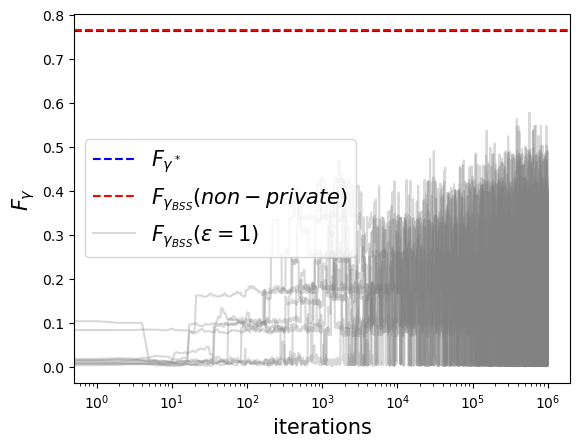

In [3]:
get_graph(1, 1000000, "strong", 10, "Uniform")

F_gamma^* : 0.7625212045676067
F_gamma_BSS : 0.764288681558088
eps_3_iter_1000000_strong
Mean F1 score: 0.8700


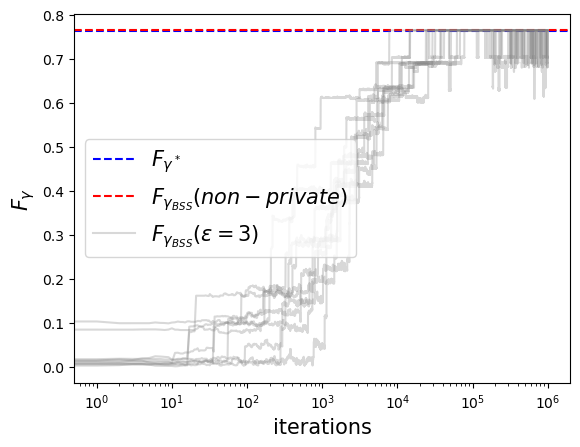

In [4]:
get_graph(3, 1000000, "strong", 10, "Uniform")

F_gamma^* : 0.7625212045676067
F_gamma_BSS : 0.764288681558088
eps_5_iter_1000000_strong
Mean F1 score: 0.9000


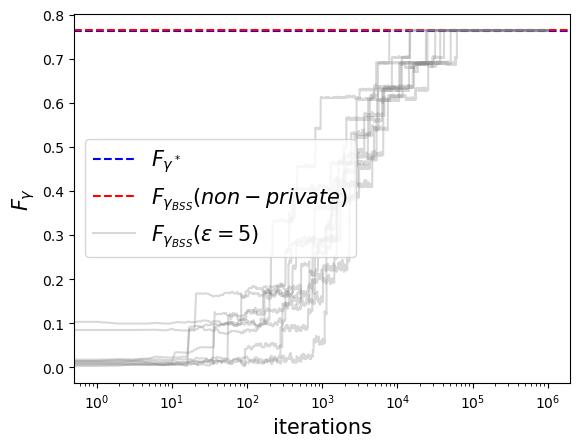

In [5]:
get_graph(5, 1000000, "strong", 10, "Uniform")

F_gamma^* : 0.7625212045676067
F_gamma_BSS : 0.764288681558088
eps_10_iter_1000000_strong
Mean F1 score: 0.9000


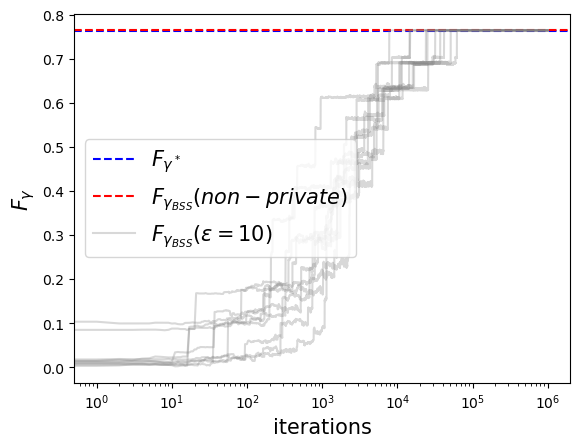

In [6]:
get_graph(10, 1000000, "strong", 10, "Uniform")

## Uniform, Weak signal

F_gamma^* : 0.25608028653345083
F_gamma_BSS : 0.2616170376102088
eps_1_iter_1000000_weak
Mean F1 score: 0.0400


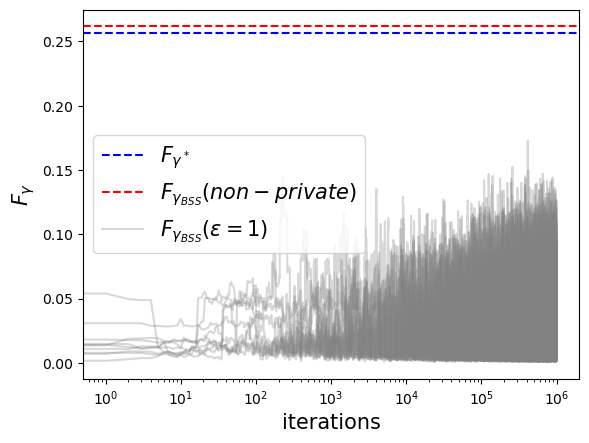

In [7]:
get_graph(1, 1000000, "weak", 10, "Uniform")

F_gamma^* : 0.25608028653345083
F_gamma_BSS : 0.2616170376102088
eps_3_iter_1000000_weak
Mean F1 score: 0.5400


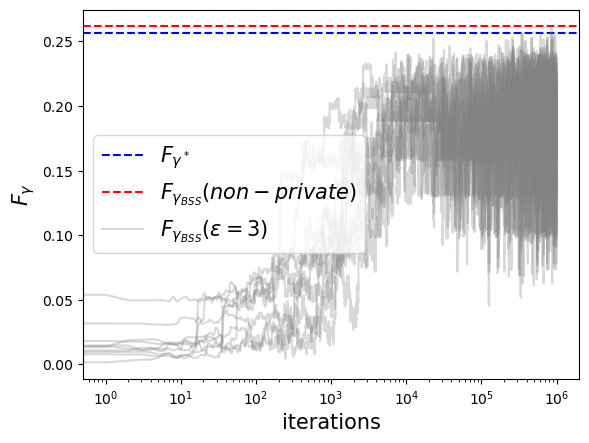

In [8]:
get_graph(3, 1000000, "weak", 10, "Uniform")

F_gamma^* : 0.25608028653345083
F_gamma_BSS : 0.2616170376102088
eps_5_iter_1000000_weak
Mean F1 score: 0.7700


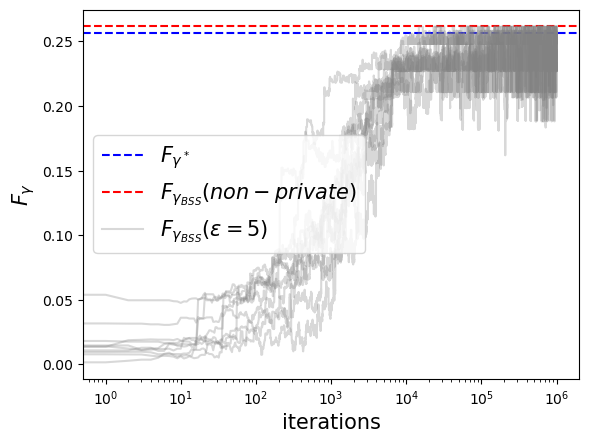

In [9]:
get_graph(5, 1000000, "weak", 10, "Uniform")

F_gamma^* : 0.25608028653345083
F_gamma_BSS : 0.2616170376102088
eps_10_iter_1000000_weak
Mean F1 score: 0.8700


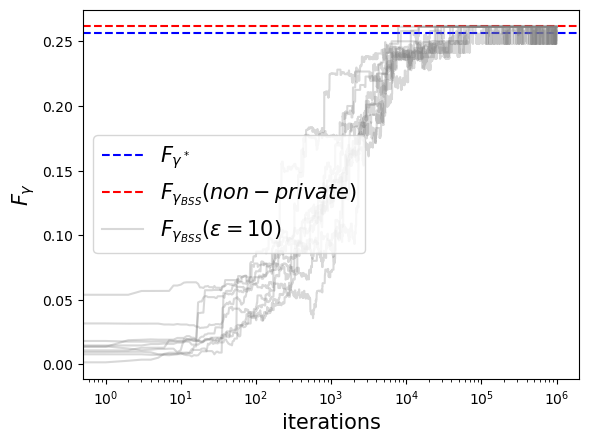

In [10]:
get_graph(10, 1000000, "weak", 10, "Uniform")

## AR1, Strong signal

F_gamma^* : 0.8826578231125727
F_gamma_BSS : 0.8826738090994196
eps_1_iter_1000000_strong
Mean F1 score: 0.8500


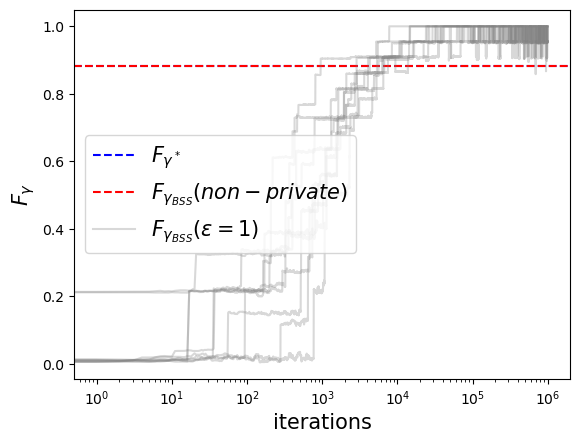

In [11]:
get_graph(1, 1000000, "strong", 10, "AR1")

F_gamma^* : 0.8826578231125727
F_gamma_BSS : 0.8826738090994196
eps_3_iter_1000000_strong
Mean F1 score: 0.9000


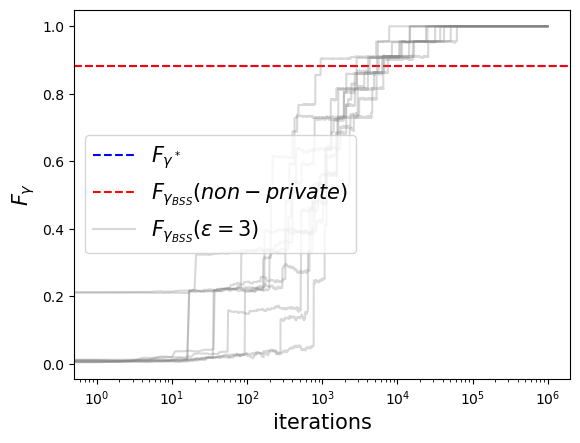

In [12]:
get_graph(3, 1000000, "strong", 10, "AR1")

F_gamma^* : 0.8826578231125727
F_gamma_BSS : 0.8826738090994196
eps_5_iter_1000000_strong
Mean F1 score: 0.9000


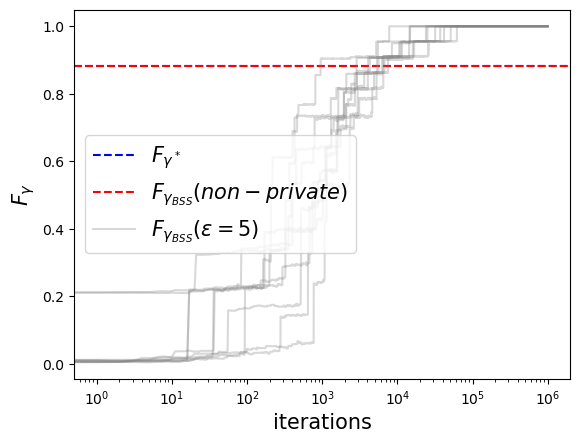

In [13]:
get_graph(5, 1000000, "strong", 10, "AR1")

F_gamma^* : 0.8826578231125727
F_gamma_BSS : 0.8826738090994196
eps_10_iter_1000000_strong
Mean F1 score: 0.9000


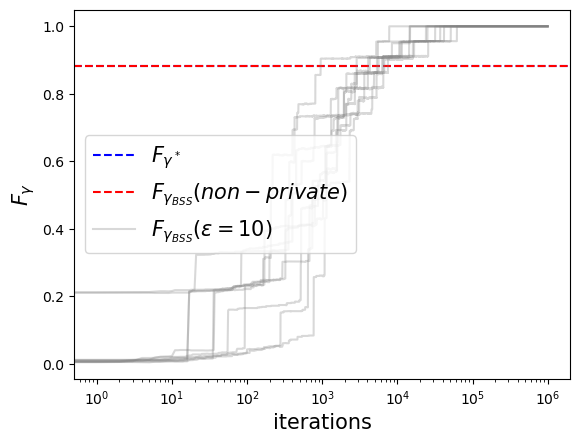

In [14]:
get_graph(10, 1000000, "strong", 10, "AR1")

## AR1, Weak signal

F_gamma^* : 0.42564408998407566
F_gamma_BSS : 0.42572233675149185
eps_1_iter_1000000_weak
Mean F1 score: 0.6100


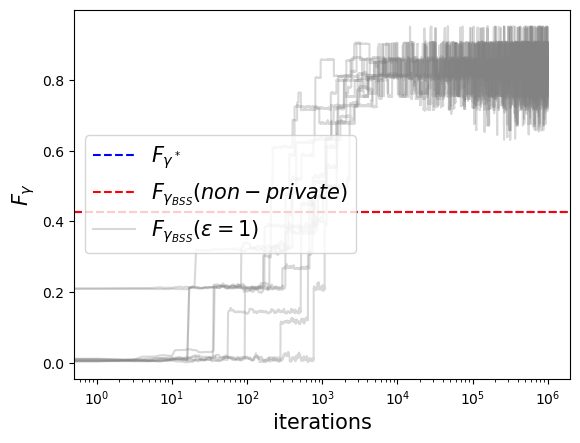

In [15]:
get_graph(1, 1000000, "weak", 10, "AR1")

F_gamma^* : 0.42564408998407566
F_gamma_BSS : 0.42572233675149185
eps_3_iter_1000000_weak
Mean F1 score: 0.9000


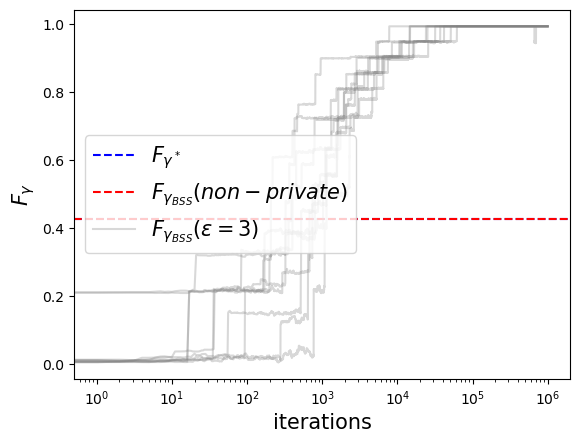

In [16]:
get_graph(3, 1000000, "weak", 10, "AR1")

F_gamma^* : 0.42564408998407566
F_gamma_BSS : 0.42572233675149185
eps_5_iter_1000000_weak
Mean F1 score: 0.9000


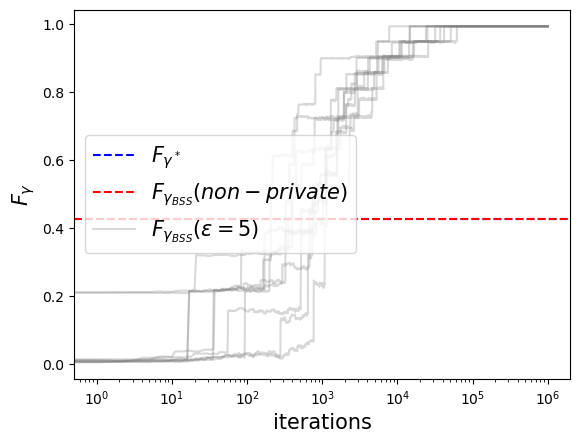

In [17]:
get_graph(5, 1000000, "weak", 10, "AR1")

F_gamma^* : 0.42564408998407566
F_gamma_BSS : 0.42572233675149185
eps_10_iter_1000000_weak
Mean F1 score: 0.9000


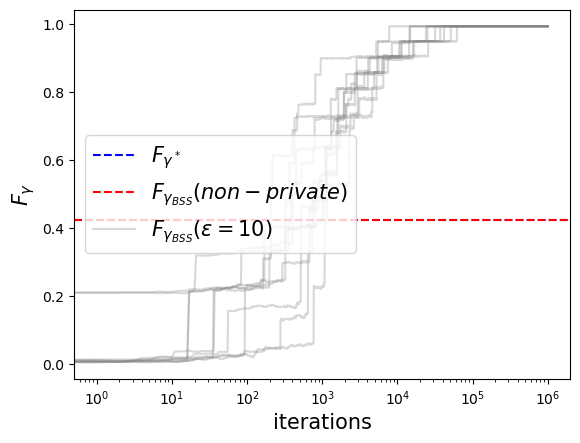

In [18]:
get_graph(10, 1000000, "weak", 10, "AR1")